H0=69.4 km/s/Mpc, b=-14.5, chi2r=0.68


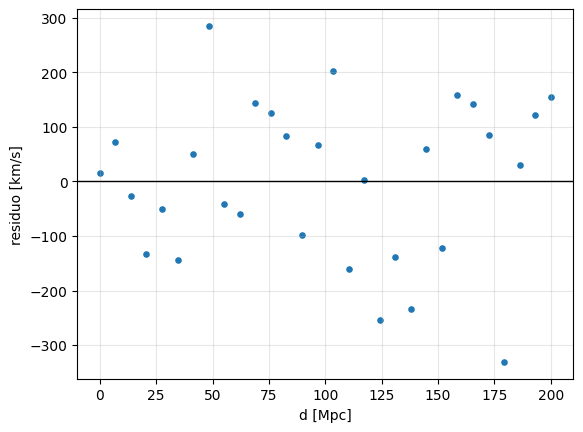

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(7)
H0_true, sigma_v = 70.0, 180.0
d = np.linspace(0, 200, 30)
v_obs = H0_true*d + rng.normal(0, sigma_v, d.size)

m, b = np.polyfit(d, v_obs, 1)
v_fit = m*d + b
res = v_obs - v_fit
chi2r = np.sum((res/sigma_v)**2)/(d.size-2)
print(f"H0={m:.1f} km/s/Mpc, b={b:.1f}, chi2r={chi2r:.2f}")

plt.scatter(d, res, s=14)
plt.axhline(0, color='k', lw=1)
plt.xlabel('d [Mpc]'); plt.ylabel('residuo [km/s]')
plt.grid(alpha=0.3); plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos originales (del ejemplo anterior)
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 25)
y_true = 2.5 * x + 5.0

# Crear incertidumbres variables para cada punto
rng2 = np.random.default_rng(0)
sigma_i = rng2.uniform(1.0, 3.0, size=x.size)  # σ entre 1 y 3

# Generar observaciones con ruido proporcional a sigma_i
y_obs = y_true + rng.normal(0, 1, size=x.size) * sigma_i

In [2]:
# Ajuste estándar: todos los puntos pesan igual
m_sin, b_sin = np.polyfit(x, y_obs, deg=1)
y_fit_sin = m_sin * x + b_sin

print(f"\nAjuste SIN ponderación:")
print(f"  Pendiente m = {m_sin:.3f} (real: 2.500)")
print(f"  Intercepto b = {b_sin:.3f} (real: 5.000)")

# Calcular chi^2 sin ponderar (asumiendo σ=1 para todos)
res_sin = y_obs - y_fit_sin
chi2_sin = np.sum(res_sin**2)
print(f"  Suma de residuos² = {chi2_sin:.2f}")


Ajuste SIN ponderación:
  Pendiente m = 2.628 (real: 2.500)
  Intercepto b = 4.136 (real: 5.000)
  Suma de residuos² = 73.26


In [3]:
# Calcular pesos: w = 1/σ
w = 1.0 / sigma_i

# Ajuste ponderado: puntos precisos pesan más
m_con, b_con = np.polyfit(x, y_obs, deg=1, w=w)
y_fit_con = m_con * x + b_con

print(f"\nAjuste CON ponderación:")
print(f"  Pendiente m = {m_con:.3f} (real: 2.500)")
print(f"  Intercepto b = {b_con:.3f} (real: 5.000)")

# Calcular chi^2 ponderado correctamente
res_con = y_obs - y_fit_con
chi2_con = np.sum((res_con / sigma_i)**2)
print(f"  χ² ponderado = {chi2_con:.2f}")


Ajuste CON ponderación:
  Pendiente m = 2.484 (real: 2.500)
  Intercepto b = 5.183 (real: 5.000)
  χ² ponderado = 16.49


In [11]:
np.linspace(0, 10, 11)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

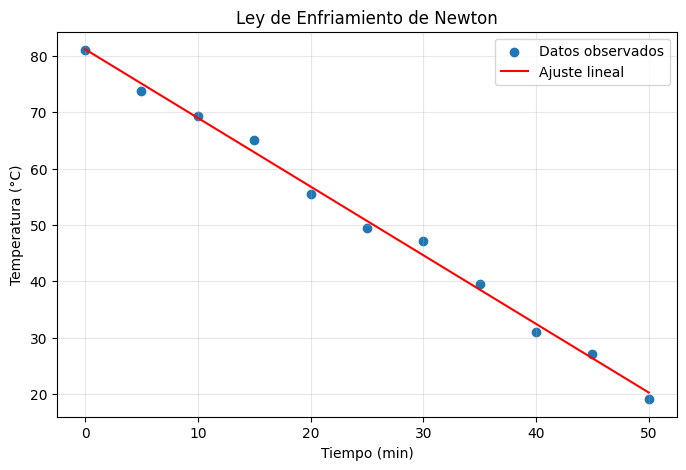

T0 = 81.196 °C
α = 1.219 °C/min
R² = 0.9949
Calidad del ajuste: Bueno

χ² = 8.9306
ν = 10
χ²_red = 0.8931


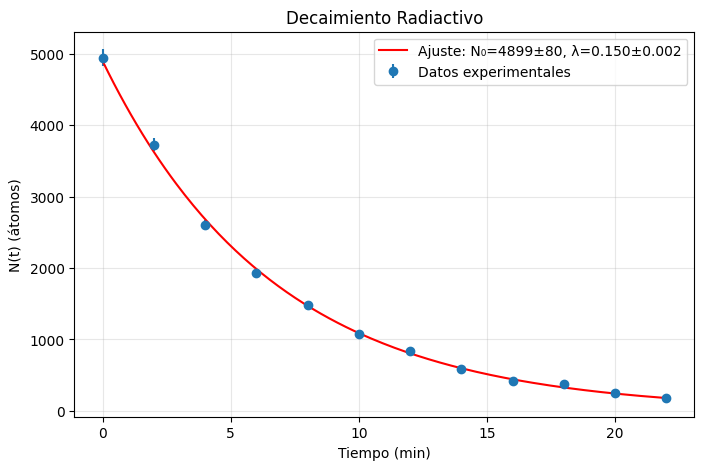


N₀ = (4899 ± 80) átomos
λ = (0.1504 ± 0.0021) min⁻¹


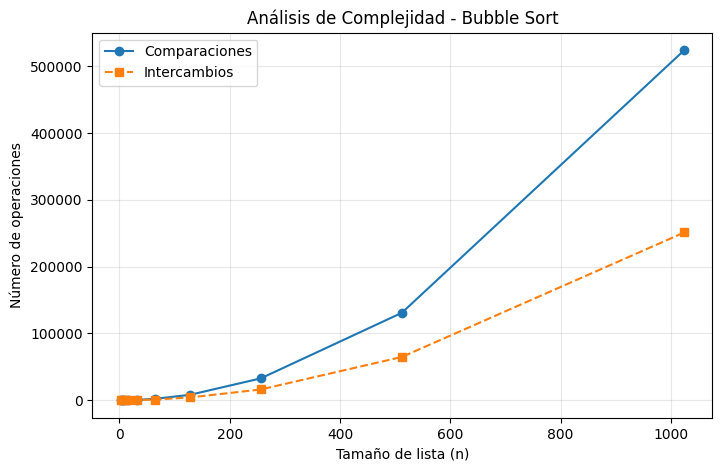


Análisis completado para las 3 preguntas


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==============================================================================
# GENERACIÓN DE DATOS SINTÉTICOS (proporcionados a los estudiantes)
# ==============================================================================

# Pregunta 1: Enfriamiento de Newton
np.random.seed(42)
t_enfriamiento = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
T_real = 80 - 1.2 * t_enfriamiento
T_obs = T_real + np.random.normal(0, 2, len(t_enfriamiento))

# Pregunta 2: Decaimiento Radiactivo
t_decaimiento = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22])
N0_real, lambda_real = 5000, 0.15
N_real = N0_real * np.exp(-lambda_real * t_decaimiento)
sigma_N = 20 + 0.02 * N_real
N_obs = N_real + np.random.normal(0, sigma_N)

# Pregunta 3: Listas para Bubble Sort
Lista_1 = np.random.randint(1, 100, size=2**1).tolist()
Lista_2 = np.random.randint(1, 100, size=2**2).tolist()
Lista_3 = np.random.randint(1, 100, size=2**3).tolist()
Lista_4 = np.random.randint(1, 100, size=2**4).tolist()
Lista_5 = np.random.randint(1, 100, size=2**5).tolist()
Lista_6 = np.random.randint(1, 100, size=2**6).tolist()
Lista_7 = np.random.randint(1, 100, size=2**7).tolist()
Lista_8 = np.random.randint(1, 100, size=2**8).tolist()
Lista_9 = np.random.randint(1, 100, size=2**9).tolist()
Lista_10 = np.random.randint(1, 100, size=2**10).tolist()


# ==============================================================================
# PREGUNTA 1: LEY DE ENFRIAMIENTO (np.polyfit)
# ==============================================================================

# Tarea 1: Ajuste lineal
coef = np.polyfit(t_enfriamiento, T_obs, deg=1)
alpha_estimado = -coef[0]
T0_estimado = coef[1]
T_estimado = T0_estimado - alpha_estimado * t_enfriamiento

# Tarea 2: Cálculo de R²
SS_res = np.sum((T_obs - T_estimado)**2)
SS_tot = np.sum((T_obs - np.mean(T_obs))**2)
R2 = 1 - (SS_res / SS_tot)

# Tarea 3: Visualización
plt.figure(figsize=(8, 5))
plt.scatter(t_enfriamiento, T_obs, label='Datos observados')
plt.plot(t_enfriamiento, T_estimado, 'r-', label='Ajuste lineal')
plt.xlabel('Tiempo (min)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Ley de Enfriamiento de Newton')
plt.show()

# Tarea 4: Reporte
print(f"T0 = {T0_estimado:.3f} °C")
print(f"α = {alpha_estimado:.3f} °C/min")
print(f"R² = {R2:.4f}")
print(f"Calidad del ajuste: {'Bueno' if R2 > 0.95 else 'Regular'}")


# ==============================================================================
# PREGUNTA 2: DECAIMIENTO RADIACTIVO (curve_fit)
# ==============================================================================

# Tarea 1: Definir modelo
def modelo_decaimiento(t, N0, lambd):
    return N0 * np.exp(-lambd * t)

# Tarea 2: Ajuste no lineal
p0 = [4500, 0.1]
popt, pcov = curve_fit(modelo_decaimiento, t_decaimiento, N_obs, 
                       p0=p0, sigma=sigma_N, absolute_sigma=True)
N_fit = modelo_decaimiento(t_decaimiento, *popt)

# Tarea 3: Extracción de incertidumbres
perr = np.sqrt(np.diag(pcov))
sigma_N0 = perr[0]
sigma_lambda = perr[1]

# Tarea 4: Cálculo de χ² reducido
residuos = (N_obs - N_fit) / sigma_N
chi2 = np.sum(residuos**2)
nu = len(t_decaimiento) - 2
chi2_red = chi2 / nu

print(f"\nχ² = {chi2:.4f}")
print(f"ν = {nu}")
print(f"χ²_red = {chi2_red:.4f}")

# Tarea 5: Visualización con barras de error
t_fino = np.linspace(0, 22, 200)
N_fino = modelo_decaimiento(t_fino, *popt)

plt.figure(figsize=(8, 5))
plt.errorbar(t_decaimiento, N_obs, yerr=sigma_N, fmt='o', label='Datos experimentales')
plt.plot(t_fino, N_fino, 'r-', label=f'Ajuste: N₀={popt[0]:.0f}±{sigma_N0:.0f}, λ={popt[1]:.3f}±{sigma_lambda:.3f}')
plt.xlabel('Tiempo (min)')
plt.ylabel('N(t) (átomos)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Decaimiento Radiactivo')
plt.show()

# Tarea 6: Reporte completo
print(f"\nN₀ = ({popt[0]:.0f} ± {sigma_N0:.0f}) átomos")
print(f"λ = ({popt[1]:.4f} ± {sigma_lambda:.4f}) min⁻¹")


# ==============================================================================
# PREGUNTA 3: ANÁLISIS DE COMPLEJIDAD BUBBLE SORT
# ==============================================================================

# Tarea 1: Instrumentación del algoritmo
def bubble_sort_instrumentado(lst):
    n = len(lst)
    comparaciones = 0
    intercambios = 0
    
    for i in range(n-1):
        for j in range(n-1-i):
            comparaciones += 1
            if lst[j] > lst[j+1]:
                lst[j], lst[j+1] = lst[j+1], lst[j]
                intercambios += 1
    
    return lst, comparaciones, intercambios

# Tarea 2: Análisis experimental
longitud_lista = []
num_comparaciones = []
num_intercambios = []

for i in range(1, 11):
    lista = eval(f"Lista_{i}").copy()
    lista_ord, comp, inter = bubble_sort_instrumentado(lista)
    
    longitud_lista.append(len(lista))
    num_comparaciones.append(comp)
    num_intercambios.append(inter)

# Tarea 3: Visualización
plt.figure(figsize=(8, 5))
plt.plot(longitud_lista, num_comparaciones, 'o-', label='Comparaciones')
plt.plot(longitud_lista, num_intercambios, 's--', label='Intercambios')
plt.xlabel('Tamaño de lista (n)')
plt.ylabel('Número de operaciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Análisis de Complejidad - Bubble Sort')
plt.show()

print("\nAnálisis completado para las 3 preguntas")